# Models

## Phase 1 : Baseline Model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Historical data: Linear Regression

In [ ]:
df = pd.read_csv('/content/historical_data.csv')

In [ ]:
df.head()

,date,Open,High,Low,Close,Volume
0,2024-11-27,233.905770,235.122835,233.247355,234.364655,33498400
1,2024-11-26,232.768491,235.003106,232.768491,234.494324,45986200
2,2024-11-26,232.768491,235.003106,232.768491,234.494324,45986200
3,2024-11-26,232.768491,235.003106,232.768491,234.494324,45986200
4,2024-11-26,232.768491,235.003106,232.768491,234.494324,45986200


In [ ]:
# Sort by date
df = df.sort_values('date')

In [ ]:
# Split data by date
split_date = '2023-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

In [ ]:
# Target Variable
train_df['Target'] = train_df['Close'].shift(-1)
test_df['Target'] = test_df['Close'].shift(-1)

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

In [ ]:
#Features
features = ['Open', 'High', 'Low', 'Volume']

X_train = train_df[features]
y_train = train_df['Target']

X_test = test_df[features]
y_test = test_df['Target']

#### Model

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.8341085509163019
RMSE: 1.1564910247120865
R² Score: 0.9974802459699604


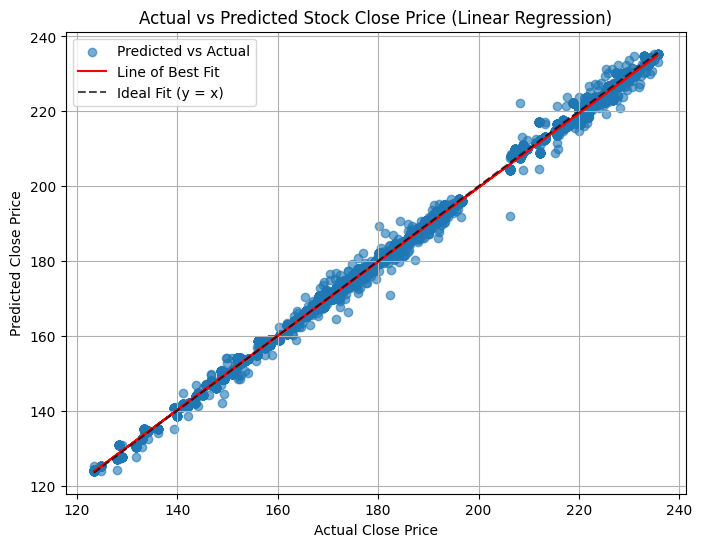

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot actual vs predicted
plt.scatter(y_test.values, y_pred, alpha=0.6, label='Predicted vs Actual')

# Line of best fit
fit = np.polyfit(y_test.values, y_pred, 1)  # slope and intercept
fit_fn = np.poly1d(fit)
plt.plot(y_test.values, fit_fn(y_test.values), color='red', label='Line of Best Fit')

# Reference line y = x (perfect prediction)
lims = [min(y_test.values.min(), y_pred.min()), max(y_test.values.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', alpha=0.7, label='Ideal Fit (y = x)')

plt.title('Actual vs Predicted Stock Close Price (Linear Regression)')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Merged Data: Linear Regression

In [ ]:
data = pd.read_csv('/content/merged_data.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26581 entries, 0 to 26580
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               26581 non-null  object 
 1   title              26581 non-null  object 
 2   content            26581 non-null  object 
 3   symbols            26581 non-null  object 
 4   tokenized_title    26581 non-null  object 
 5   tokenized_content  26581 non-null  object 
 6   sentiment          26581 non-null  object 
 7   sentiment_score    26581 non-null  float64
 8   Open               26581 non-null  float64
 9   High               26581 non-null  float64
 10  Low                26581 non-null  float64
 11  Close              26581 non-null  float64
 12  Volume             26581 non-null  int64  
 13  SMA_20             26581 non-null  float64
 14  SMA_5              26581 non-null  float64
 15  SMA_diff           26581 non-null  float64
 16  EMA                265

In [ ]:
data.columns.tolist()

['date',
 'title',
 'content',
 'symbols',
 'tokenized_title',
 'tokenized_content',
 'sentiment',
 'sentiment_score',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'SMA_20',
 'SMA_5',
 'SMA_diff',
 'EMA',
 'RSI']

In [ ]:
# Sort by date
data = data.sort_values('date')

In [ ]:
''' Training set: 2016–2022 | Testing set: 2023–2024 '''

# Split by date
train_data = data[data['date'] < '2023-01-01']
test_data = data[data['date'] >= '2023-01-01']

In [ ]:
# Target Variable
train_data['m_Target'] = train_data['Close'].shift(-1)
test_data['m_Target'] = test_data['Close'].shift(-1)

train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

<ipython-input-50-7555d06476da>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['m_Target'] = train_data['Close'].shift(-1)
<ipython-input-50-7555d06476da>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['m_Target'] = test_data['Close'].shift(-1)
<ipython-input-50-7555d06476da>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [ ]:
#Features
m_features = ['sentiment_score', 'Open', 'High', 'Low', 'Volume',
            'SMA_20', 'SMA_5', 'SMA_diff', 'EMA', 'RSI']

X_train_data = train_data[m_features]
y_train_data = train_data['m_Target']

X_test_data = test_data[m_features]
y_test_data = test_data['m_Target']

#### Model

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scale = scaler.fit_transform(X_train_data)
X_test_scale = scaler.transform(X_test_data)

In [ ]:
reg2 = LinearRegression()
reg2.fit(X_train_scale, y_train_data)

LinearRegression()

In [ ]:
y_pred_data = reg2.predict(X_test_scale)

print("MAE:", mean_absolute_error(y_test_data, y_pred_data))
print("RMSE:", np.sqrt(mean_squared_error(y_test_data, y_pred_data)))
print("R² Score:", r2_score(y_test_data, y_pred_data))

MAE: 0.7976362067164248
RMSE: 1.1087692247384082
R² Score: 0.9976839072810851


### Analysis:

Comparing the linear regression models using historical data alone versus merged data that includes sentiment analysis scores reveals a slight performance improvement with the inclusion of sentiment features. Specifically, the MAE is 0.036% lower, RMSE is reduced by 0.047%, and the R² score is 0.0002% higher when sentiment data is included. While the improvement is modest, it indicates that sentiment analysis contributes additional predictive signals beyond traditional technical indicators, enhancing the model’s accuracy in forecasting next-day closing prices.






**Additional Analyis based off of Merged Data set**:

R² value of 0.998 is very high: Variance in the target (next-day Close price). That’s typically unusual in stock price prediction unless:


- Price Series is Very Smooth

- Apple's stock price doesn't change drastically day to day. So, predicting the next-day close from today’s data is sometimes just guessing “very close to today”, which the model can easily learn.



In [ ]:

feature_coefficients = pd.DataFrame({
    'Feature': m_features,
    'Coefficient': reg2.coef_
})

# Add absolute values for sorting
feature_coefficients['Abs_Coefficient'] = feature_coefficients['Coefficient'].abs()

# Sort by absolute coefficient value
feature_coefficients = feature_coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print(feature_coefficients[['Feature', 'Coefficient']])

           Feature  Coefficient
3              Low    14.791631
2             High    13.539743
1             Open   -12.305454
9              RSI     0.622607
5           SMA_20     0.382135
7         SMA_diff     0.349163
6            SMA_5     0.274852
8              EMA     0.257963
4           Volume     0.112087
0  sentiment_score     0.000637


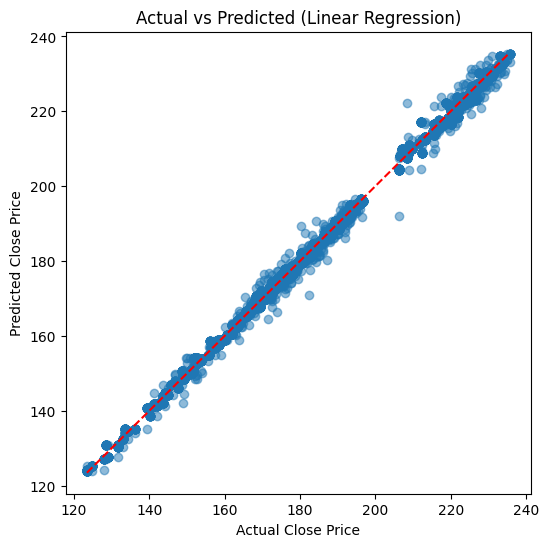

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

## Phase 2: Tree Based Models

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
rf.fit(X_train_data, y_train_data)
y_pred = rf.predict(X_test_data)

# Evaluate
print(f"MAE: {mean_absolute_error(y_test_data, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_data, y_pred)):.4f}")
print(f"R² Score: {r2_score(y_test_data, y_pred):.4f}")

MAE: 12.9165
RMSE: 20.8794
R² Score: 0.1787


#### Analysis

Linear Regression significantly outperformed Random Forest, likely due to the underlying linear nature of the problem and the time-dependent structure of stock data. Random Forest, being non-sequential, was unable to model this effectively.

#### XGBoost

In [ ]:
!pip install xgboost

In [ ]:
!pip install tqdm
!pip install -U tqdm

In [ ]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

##### xgboost model with grid search and cross validation

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, make_scorer
from tqdm import tqdm

# Model and parameters
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# Scoring and CV
scorer = make_scorer(mean_absolute_error, greater_is_better=False)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
results = []
for params in tqdm(list(ParameterGrid(param_grid)), desc="Grid Search Progress"):
    xgb.set_params(**params)
    scores = cross_val_score(xgb, X_train_data, y_train_data, scoring=scorer, cv=cv, n_jobs=-1)
    results.append((params, scores.mean()))

# Find best parameters
best_params, best_score = sorted(results, key=lambda x: x[1], reverse=True)[0]
print("Best Parameters:", best_params)


Grid Search Progress: 100%|██████████| 2187/2187 [1:17:50<00:00,  2.14s/it]

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}


In [ ]:
# Train the best model using the best parameters found
best_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
best_model.fit(X_train_data, y_train_data)

# Predict on the test set
ypred = best_model.predict(X_test_data)

# Evaluate
mae = mean_absolute_error(y_test_data, ypred)
rmse = np.sqrt(mean_squared_error(y_test_data, ypred))
r2 = r2_score(y_test_data, ypred)

# Print results
print("Best Parameters:", best_params)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
MAE: 12.5809
RMSE: 20.5828
R² Score: 0.2019


#### Additonal feature engineering to handle time series data for tree based model : Adding Lag features

In [ ]:
# Load data
data = pd.read_csv('/content/merged_data.csv')

# Convert date column to datetime if it's not already
data['date'] = pd.to_datetime(data['date'])

# Sort by date to ensure correct lagging
data = data.sort_values('date')

# Define columns to lag
lag_features = ['sentiment_score', 'Close', 'Open', 'High', 'Low', 'Volume', 'RSI']

# Create lag features
for col in lag_features:
    data[f'{col}_lag_1'] = data[col].shift(1)
    data[f'{col}_lag_2'] = data[col].shift(2)

# Create target column
data['m_Target'] = data['Close'].shift(-1)

# Drop rows with NaN from lagging and shifting
data.dropna(inplace=True)

# Split into train/test after lag features are created
train_data = data[data['date'] < '2023-01-01']
test_data = data[data['date'] >= '2023-01-01']

# Feature columns
l_features = [
    'sentiment_score', 'Open', 'High', 'Low', 'Volume',
    'SMA_20', 'SMA_5', 'SMA_diff', 'EMA', 'RSI',
    'sentiment_score_lag_1', 'sentiment_score_lag_2',
    'Close_lag_1', 'Close_lag_2',
    'Open_lag_1', 'Open_lag_2',
    'High_lag_1', 'High_lag_2',
    'Low_lag_1', 'Low_lag_2',
    'Volume_lag_1', 'Volume_lag_2',
    'RSI_lag_1', 'RSI_lag_2'
]

# Final train-test sets
X_train_l = train_data[l_features]
y_train_l = train_data['m_Target']
X_test_l = test_data[l_features]
y_test_l = test_data['m_Target']

In [ ]:
''' Random Forest '''
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_l, y_train_l)

# Predict
rf_preds = rf_model.predict(X_test_l)

# Evaluate
rf_mae = mean_absolute_error(y_test_l, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test_l, rf_preds))
rf_r2 = r2_score(y_test_l, rf_preds)

print("Random Forest Results:")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Results:
MAE: 11.1978
RMSE: 19.2226
R² Score: 0.3039


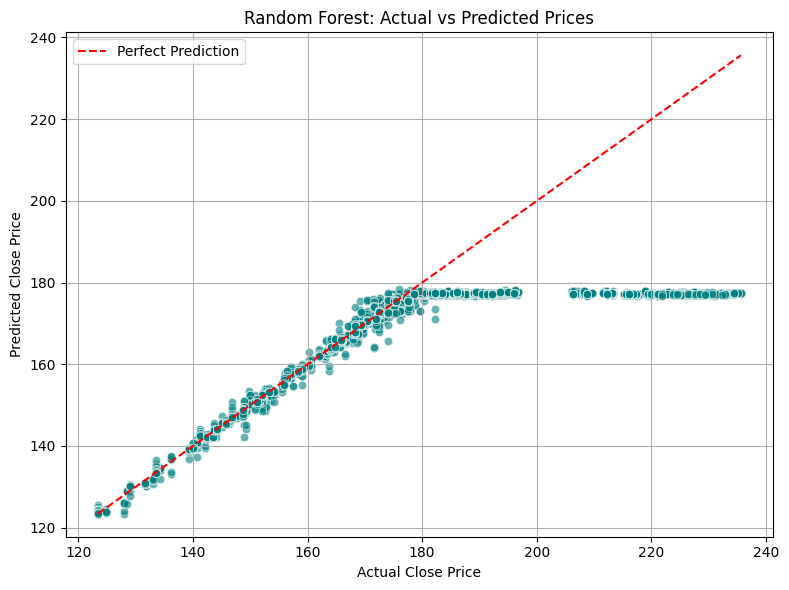

In [ ]:
# Scatter Plot showing Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_l, y=rf_preds, alpha=0.6, color='teal')
plt.plot([y_test_l.min(), y_test_l.max()], [y_test_l.min(), y_test_l.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

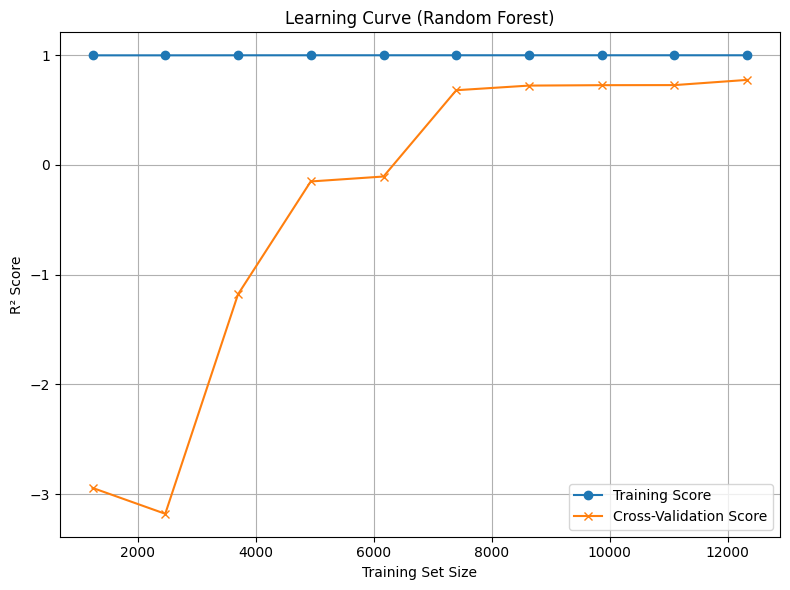

In [ ]:
#Learning curve: to see underfitting or overfitting

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train_l, y_train_l,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Calculate means
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, val_mean, label='Cross-Validation Score', marker='x')
plt.title('Learning Curve (Random Forest)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Train XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_l, y_train_l)

# Predict
xgb_preds = xgb_model.predict(X_test_l)

# Evaluate
xgb_mae = mean_absolute_error(y_test_l, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test_l, xgb_preds))
xgb_r2 = r2_score(y_test_l, xgb_preds)

print("XGBoost Results:")
print(f"MAE: {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R² Score: {xgb_r2:.4f}")

XGBoost Results:
MAE: 11.6201
RMSE: 19.8160
R² Score: 0.2602


In [ ]:
# Get feature importance scores
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
for feature, importance in sorted_importance:
    print(f"{feature}: {importance:.2f}")

High_lag_2: 34029.37
Close_lag_1: 20672.34
High: 2204.30
Close_lag_2: 846.26
Low: 583.41
Open: 238.47
SMA_20: 236.40
SMA_diff: 46.09
RSI_lag_2: 26.32
SMA_5: 25.25
Volume_lag_2: 19.88
Open_lag_2: 10.51
RSI: 9.52
Low_lag_2: 8.75
High_lag_1: 8.51
Low_lag_1: 6.94
Volume_lag_1: 6.69
RSI_lag_1: 5.98
Volume: 5.35
sentiment_score: 3.28
sentiment_score_lag_2: 3.20
Open_lag_1: 2.98
sentiment_score_lag_1: 2.97
EMA: 2.15


#### Analysis

The initial performance of both Random Forest and XGBoost models was relatively poor, with high MAE and RMSE values and low R² scores, indicating limited ability to capture the temporal dynamics of stock price movements. This is expected, as tree-based models do not inherently consider time dependencies. After introducing lag features to embed sequential context, both models showed noticeable improvement. Random Forest's MAE dropped from 12.58 to 11.20, and its R² increased from 0.20 to 0.30, while XGBoost showed a similar trend with improved metrics. These results highlight that incorporating lag-based features can help tree-based models better handle time-series data. However, even with these enhancements, their performance remained inferior to models like linear regression and LSTM.

## Phase 3: Deep Learning with LSTM

In [ ]:
import pandas as pd
import numpy as np
merged_df = pd.read_csv('/content/merged_data.csv')

In [ ]:
# Preparing data for LSTM
# Using technical and sentiment features
features = ['Open', 'High', 'Low', 'Volume', 'SMA_20', 'SMA_5', 'SMA_diff', 'EMA', 'RSI', 'sentiment_score']
target = 'Close'

In [ ]:
# Normalizing the features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(merged_df[features + [target]])

# Converting to a numpy array
scaled_data = np.array(scaled_data)

In [ ]:
# Creating sequences
def create_sequences(data, sequence_length):
   X = []
   y = []
   for i in range(sequence_length, len(data)):
    X.append(data[i-sequence_length:i, :-1])
    y.append(data[i, -1])
   return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)


In [ ]:
# Train-Test Split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Building the LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# first lstm layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second lstm layer (no return_sequences)
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=1))
model.compile(optimizer='adam', loss = 'mean_squared_error')

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,451 (126.76 KB)

 Trainable params: 32,451 (126.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training LSTM
final_data = model.fit(X_train, y_train, epochs=20,
                       batch_size=32, validation_data=(X_test, y_test),
                       verbose=1)

Epoch 1/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0179 - val_loss: 1.8861e-04
Epoch 2/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0027 - val_loss: 1.8796e-04
Epoch 3/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0020 - val_loss: 3.0523e-04
Epoch 4/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0016 - val_loss: 3.7823e-04
Epoch 5/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0011 - val_loss: 6.3507e-04
Epoch 6/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7.9106e-04 - val_loss: 2.2115e-04
Epoch 7/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 5.1328e-04 - val_loss: 4.0246e-04
Epoch 8/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 3.5551e-04 - val_loss: 4.1894e-04
Epoch 9/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 2.5537e-04 - val_loss: 1.6914e-04
Epoch 10/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.9995e-04 - val_loss: 2.0626e-04
Epoch 11/20
663/663 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 1.6472e-04 

In [ ]:
model.save("lstm_stock_model.h5")

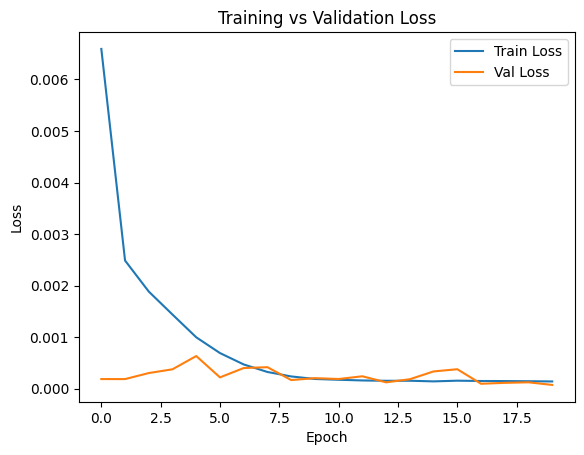

In [ ]:
import matplotlib.pyplot as plt

plt.plot(final_data.history['loss'], label='Train Loss')
plt.plot(final_data.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [ ]:
'''Use the model to predict closing prices on X_test

Inverse scale the predictions to get actual price values

Compare predictions with actual y_test

Plot actual vs predicted prices'''

# Predict on test set
y_pred_scaled = model.predict(X_test)

import numpy as np

# Function to inverse transform only the target column
def inverse_target_only(scaler, data_scaled, feature_index):
    dummy_full = np.zeros((len(data_scaled), scaler.n_features_in_))
    # Place the scaled target data into the correct column index of the dummy array
    dummy_full[:, feature_index] = data_scaled.flatten()  # Flatten y_pred_scaled before placing
    return scaler.inverse_transform(dummy_full)[:, feature_index]

# Get index of target column in the original dataframe column order used for scaling
# The columns used for scaling were features + [target]
target_index = len(features)

# y_pred_scaled is already (num_samples, 1)
y_pred_unscaled = inverse_target_only(scaler, y_pred_scaled, target_index)
y_test_unscaled = inverse_target_only(scaler, y_test.reshape(-1, 1), target_index)

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Calculate metrics
r2 = r2_score(y_test_unscaled, y_pred_unscaled)
mae = mean_absolute_error(y_test_unscaled, y_pred_unscaled)
rmse = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled))

# Print results
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

R-squared (R²): 0.9841
Mean Absolute Error (MAE): 1.0395
Root Mean Squared Error (RMSE): 1.8510


### Analysis

Analyzing the performance of the LSTM model in Phase 3, we observe its R², MAE, and RMSE metrics on the test set. Comparing these values to the linear regression, Random Forest, and XGBoost models from the previous phases reveals how well the LSTM captured the patterns in the merged data, which includes both historical price information, technical indicators, and sentiment scores. The training and validation loss plot provides insight into the model's learning process, indicating whether it converged effectively and if overfitting or underfitting was a significant issue.

The choice of an LSTM was motivated by its suitability for time series data, allowing it to potentially capture temporal dependencies in stock prices. By comparing the LSTM's performance to models that don't explicitly handle sequences (like tree-based methods), we can assess the value of this architectural choice for this specific prediction task. Considering the limitations of the current model setup and the potential for further improvement, future work could focus on optimizing the LSTM's architecture, exploring different feature sets, and applying more rigorous evaluation techniques to enhance the model's predictive capabilities.